# 📁 SECTION 1: Data Setup and Initial Exploration

## 📝 **Research Notebook Documentation**

This document provides a detailed, step-by-step explanation of the methodology and implementation within this notebook, suitable for a research thesis or comprehensive documentation. Each section outlines the objectives, methods, and specific code implementations for QR code classification.

### 📁 **SECTION 1: Data Setup and Initial Exploration**

**Objective:** The primary goal of this section is to establish access to the necessary dataset stored on Google Drive and perform an initial verification of the data structure. This ensures that the raw image files, categorized as 'benign' and 'malicious' QR codes, are correctly identified and accessible for subsequent processing.

**Methodology:**

1.  **Google Drive Mounting:** The first step involves mounting Google Drive to the Colab environment. This is crucial for accessing datasets that are typically stored in a user's Drive.
2.  **Directory Verification:** After mounting, the notebook verifies the existence of the main dataset directory and its subdirectories (`benign` and `malicious`). This ensures that the expected file structure is present.
3.  **File Count Validation:** For each category (benign and malicious), the notebook iterates through the respective directories to count the number of image files. This provides an initial quantitative overview of the dataset size and helps confirm data integrity.

**Implementation Details:**

In [19]:
from google.colab import drive
# Remounting with force_remount=True to resolve the I/O error
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


**Code Explanation (Cell `d960dfed`):**

*   `from google.colab import drive`: Imports the necessary module for Google Drive interaction in Colab.
*   `drive.mount('/content/drive', force_remount=True)`: This command mounts the user's Google Drive to the `/content/drive` directory within the Colab environment. `force_remount=True` is used to address potential I/O errors by ensuring a fresh mount, which is often helpful in Colab sessions.

In [20]:
import os
from pathlib import Path

directory_path = Path('/content/drive/MyDrive/My-Study-and-Carrier/qr_codes')

if directory_path.is_dir():
    print(f"--- Directory exists: {directory_path} ---")

    for label in ['benign', 'malicious']:
        nested_path = directory_path / label / label
        print(f"Checking {label} folder...")
        try:
            if nested_path.is_dir():
                # Using os.scandir for better performance on large directories
                count = 0
                with os.scandir(nested_path) as it:
                    for entry in it:
                        if entry.is_file():
                            count += 1
                print(f"Found {count} files in: {nested_path}")
            else:
                print(f"Path not found: {nested_path}")
        except OSError as e:
            print(f"Error accessing {label} directory: {e}")
            print("Suggestion: Try to refresh the Drive tab or wait a few minutes for the indexing to catch up.")
else:
    print(f"The directory '{directory_path}' does not exist.")

--- Directory exists: /content/drive/MyDrive/My-Study-and-Carrier/qr_codes ---
Checking benign folder...
Found 100001 files in: /content/drive/MyDrive/My-Study-and-Carrier/qr_codes/benign/benign
Checking malicious folder...
Found 100000 files in: /content/drive/MyDrive/My-Study-and-Carrier/qr_codes/malicious/malicious


**Code Explanation (Cell `ae7054ab`):**

*   `import os` and `from pathlib import Path`: These lines import modules for file system interaction. `pathlib` provides an object-oriented way to handle file paths, which is generally more robust than `os.path`.
*   `directory_path = Path('/content/drive/MyDrive/My-Study-and-Carrier/qr_codes')`: Defines the root path where the QR code dataset is expected to be located.
*   `if directory_path.is_dir():`: Checks if the specified root directory exists.
*   `for label in ['benign', 'malicious']:`: Iterates through the two main categories of QR codes.
*   `nested_path = directory_path / label / label`: Constructs the full path to the directory containing images for a specific label (e.g., `/qr_codes/benign/benign`).
*   `if nested_path.is_dir():`: Verifies that the specific category directory exists.
*   `with os.scandir(nested_path) as it:`: Uses `os.scandir` for efficient directory listing. This is generally faster for counting files than `os.listdir` for large directories.
*   `for entry in it: if entry.is_file(): count += 1`: Iterates through directory entries and increments a counter if the entry is a file.
*   `print(...)`: Outputs the number of files found in each category.
*   `except OSError as e:`: Includes error handling for potential issues when accessing directories, providing a helpful suggestion to the user.

## 🖼️ SECTION 2: Image Preprocessing Function

### 🖼️ **SECTION 2: Image Preprocessing Function**

**Objective:** To define a standardized function for preprocessing individual QR code images. This function prepares images for consumption by a Convolutional Neural Network (CNN) by ensuring uniform dimensions and pixel value ranges.

**Methodology:**

1.  **Image Loading and Color Conversion:** Images are loaded from their file paths. It's crucial to convert them to a consistent color format (RGB) to ensure all images have three channels, which is a common input requirement for CNNs.
2.  **Resizing:** All images are resized to a fixed dimension (e.g., 128x128 pixels). This is a mandatory step for batch processing in neural networks, as all inputs must have identical shapes.
3.  **Normalization:** Pixel values, typically ranging from 0-255, are normalized to a 0.0-1.0 range. This normalization aids in faster and more stable model convergence during training.
4.  **Error Handling:** The function includes error handling to gracefully manage cases where an image file might be corrupted or unreadable, preventing the entire data loading process from crashing.

**Implementation Details:**

### 🖼️ SECTION 3: Load and Prepare Datasets

**Code Explanation (Cell `b85a0d12`):**

*   `import numpy as np`: Imports the NumPy library for numerical operations, particularly for handling image arrays.
*   `from pathlib import Path`: Used for object-oriented file path manipulation.
*   `from sklearn.model_selection import train_test_split`: Imports a utility for splitting datasets.
*   `import random`: Used for shuffling data.
*   `from PIL import Image`: Imports the Pillow library for image processing (loading, resizing, format conversion).
*   `IMG_HEIGHT = 128`, `IMG_WIDTH = 128`: Defines the target dimensions for all preprocessed images.
*   `image_extensions = (...)`: A tuple listing common image file extensions to filter valid image files.
*   `def preprocess_image(image_path):`: Defines the image preprocessing function.
    *   `img = Image.open(image_path).convert('RGB')`: Opens the image file and converts it to the RGB color format.
    *   `img = img.resize((IMG_WIDTH, IMG_HEIGHT))`: Resizes the image to the predefined `IMG_WIDTH` and `IMG_HEIGHT`.
    *   `img_array = np.array(img) / 255.0`: Converts the PIL Image object into a NumPy array and normalizes pixel values from 0-255 to 0.0-1.0.
    *   `return img_array`: Returns the processed image array.
    *   `except Exception as e: return None`: Catches any errors during image processing (e.g., file not found, corrupted image) and returns `None` to indicate failure, allowing the loading process to continue without crashing.

In [21]:
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split
import random
from PIL import Image

# Configuration
IMG_HEIGHT = 128
IMG_WIDTH = 128
image_extensions = ('.jpg', '.jpeg', '.png', '.gif', '.bmp', '.tiff', '.webp')

# Helper function for preprocessing
def preprocess_image(image_path):
    try:
        img = Image.open(image_path).convert('RGB')
        img = img.resize((IMG_WIDTH, IMG_HEIGHT))
        img_array = np.array(img) / 255.0
        return img_array
    except Exception as e:
        return None

def load_and_preprocess_dataset(base_dir, label, max_samples=1000):
    images = []
    labels = []
    if base_dir.is_dir():
        print(f"Loading images from: {base_dir}")
        count = 0
        for item in base_dir.iterdir():
            if count >= max_samples: break
            if item.is_file() and item.suffix.lower() in image_extensions:
                processed_img = preprocess_image(str(item))
                if processed_img is not None:
                    images.append(processed_img)
                    labels.append(label)
                    count += 1
        print(f"Found {len(images)} images in {base_dir} with label {label}.")
    else:
        print(f"Directory not found: {base_dir}")
    return images, labels

# Paths based on previous section
benign_dir = directory_path / 'benign' / 'benign'
malicious_dir = directory_path / 'malicious' / 'malicious'

# Load datasets (using 1000 samples for a quick test)
benign_images, benign_labels = load_and_preprocess_dataset(benign_dir, 0)
malicious_images, malicious_labels = load_and_preprocess_dataset(malicious_dir, 1)

# Combine and shuffle
X = np.array(benign_images + malicious_images)
y = np.array(benign_labels + malicious_labels)

combined = list(zip(X, y))
random.shuffle(combined)
X_shuffled, y_shuffled = zip(*combined)
X_shuffled = np.array(X_shuffled)
y_shuffled = np.array(y_shuffled)

# Split data
X_train, X_temp, y_train, y_temp = train_test_split(X_shuffled, y_shuffled, test_size=0.3, random_state=42, stratify=y_shuffled)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"\nTraining set: {len(X_train)}, Validation: {len(X_val)}, Test: {len(X_test)}")

Loading images from: /content/drive/MyDrive/My-Study-and-Carrier/qr_codes/benign/benign
Found 1000 images in /content/drive/MyDrive/My-Study-and-Carrier/qr_codes/benign/benign with label 0.
Loading images from: /content/drive/MyDrive/My-Study-and-Carrier/qr_codes/malicious/malicious
Found 1000 images in /content/drive/MyDrive/My-Study-and-Carrier/qr_codes/malicious/malicious with label 1.

Training set: 1400, Validation: 300, Test: 300


**Code Explanation (Cell `163c6feb` - continuation):**

*   `def load_and_preprocess_dataset(base_dir, label, max_samples=1000):`: This function loads images from a specified directory, applies the `preprocess_image` function, and assigns a numerical label.
    *   `max_samples`: Limits the number of images loaded from each directory, useful for initial testing or memory management.
    *   The function iterates through files in `base_dir`, processes valid image files using `preprocess_image`, appends the processed image array and its corresponding label to lists, and provides progress updates.
*   `benign_dir = directory_path / 'benign' / 'benign'` and `malicious_dir = directory_path / 'malicious' / 'malicious'`: Defines the specific directory paths for benign and malicious images.
*   `benign_images, benign_labels = load_and_preprocess_dataset(benign_dir, 0)` and `malicious_images, malicious_labels = load_and_preprocess_dataset(malicious_dir, 1)`: Calls the `load_and_preprocess_dataset` function to load and preprocess images from both categories, assigning `0` for benign and `1` for malicious.
*   `X = np.array(benign_images + malicious_images)`: Combines all processed image arrays into a single NumPy array `X` (features).
*   `y = np.array(benign_labels + malicious_labels)`: Combines all labels into a single NumPy array `y` (target variable).
*   `combined = list(zip(X, y))`, `random.shuffle(combined)`, `X_shuffled, y_shuffled = zip(*combined)`: These lines combine features and labels, shuffle them randomly to ensure data independence, and then separate them back into shuffled feature (`X_shuffled`) and label (`y_shuffled`) arrays.
*   `X_train, X_temp, y_train, y_temp = train_test_split(X_shuffled, y_shuffled, test_size=0.3, random_state=42, stratify=y_shuffled)`: Splits the shuffled data into training and a temporary set. `test_size=0.3` allocates 30% for temporary, and `stratify=y_shuffled` ensures that the class distribution in the split is similar to the original dataset, which is crucial for balanced datasets.
*   `X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)`: Splits the temporary set further into validation and test sets, each taking 50% of the temporary set (resulting in 15% of the total original data for validation and 15% for testing).
*   `print(...)`: Outputs the final sizes of the training, validation, and test datasets.

### ⚙️ SECTION 4: Build and Train CNN Model

### ⚙️ **SECTION 4: Build and Train CNN Model**

**Objective:** To design, compile, and train a Convolutional Neural Network (CNN) capable of classifying QR codes as either benign or malicious. This section focuses on creating a robust model architecture and optimizing its training process.

**Methodology:**

1.  **Model Architecture Definition:** A sequential CNN model is constructed, comprising convolutional layers for feature extraction, pooling layers for dimensionality reduction, and dense layers for classification. Dropout is included to mitigate overfitting.
2.  **Model Compilation:** The model is configured with an optimizer (Adam), a loss function (binary cross-entropy for binary classification), and evaluation metrics (accuracy).
3.  **Callbacks for Training Control:** Early stopping is implemented to halt training when validation performance no longer improves, preventing overfitting and saving computational resources. A learning rate scheduler is also used to adjust the learning rate during training, potentially improving convergence.
4.  **Model Training:** The compiled model is trained using the prepared training data, with performance monitored on the validation set.

**Implementation Details:**

In [22]:
from tensorflow.keras import models, layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Define the CNN model architecture
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5), # Add dropout for regularization
    layers.Dense(1, activation='sigmoid') # Sigmoid for binary classification
])

# Compile the model
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

# Callbacks for better training
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=0.00001)

print("Model defined and compiled. Starting training...")

# Train the model
history = model.fit(X_train, y_train,
                    epochs=20, # You can adjust the number of epochs
                    validation_data=(X_val, y_val),
                    callbacks=[early_stopping, reduce_lr])

print("Model training complete!")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

Model defined and compiled. Starting training...
Epoch 1/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 77s 2s/step - accuracy: 0.5607 - loss: 0.7274 - val_accuracy: 0.7667 - val_loss: 0.6685 - learning_rate: 0.0010
Epoch 2/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 73s 2s/step - accuracy: 0.6700 - loss: 0.6172 - val_accuracy: 0.8167 - val_loss: 0.4596 - learning_rate: 0.0010
Epoch 3/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 80s 2s/step - accuracy: 0.8429 - loss: 0.3598 - val_accuracy: 0.9400 - val_loss: 0.2017 - learning_rate: 0.0010
Epoch 4/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 66s 2s/step - accuracy: 0.9507 - loss: 0.1523 - val_accuracy: 0.9567 - val_loss: 0.1014 - learning_rate: 0.0010
Epoch 5/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 67s 1s/step - accuracy: 0.9793 - loss: 0.0618 - val_accuracy: 0.9733 - val_loss: 0.0793 - learning_rate: 0.0010
Epoch 6/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 68s 2s/step - accuracy: 0.9893 - loss: 0.0330 - val_accuracy: 0.9667 - val_loss: 0.0682 - learning_rate: 0.0010
Epoch 7/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 86s 2s/step -

**Code Explanation (Cell `ea124e9d`):**

*   `from tensorflow.keras import models, layers`: Imports necessary modules from Keras for building neural networks.
*   `from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau`: Imports callback functions to control the training process.
*   `model = models.Sequential([...])`: Initializes a sequential Keras model, meaning layers are stacked linearly.
    *   `layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3))`: The first convolutional layer with 32 filters, a 3x3 kernel, ReLU activation, and specifying the input shape (height, width, color channels).
    *   `layers.MaxPooling2D((2, 2))`: A max pooling layer that reduces the spatial dimensions (height and width) by taking the maximum value over 2x2 windows.
    *   `layers.Conv2D(64, (3, 3), activation='relu')`, `layers.MaxPooling2D((2, 2))`, `layers.Conv2D(128, (3, 3), activation='relu')`, `layers.MaxPooling2D((2, 2))`: Additional convolutional and pooling layers to extract increasingly complex features and further reduce dimensionality.
    *   `layers.Flatten()`: Converts the 3D output of the convolutional layers into a 1D vector, preparing it for the dense layers.
    *   `layers.Dense(128, activation='relu')`: A fully connected (dense) layer with 128 neurons and ReLU activation.
    *   `layers.Dropout(0.5)`: A dropout layer that randomly sets 50% of the input units to 0 at each update during training, which helps prevent overfitting.
    *   `layers.Dense(1, activation='sigmoid')`: The output layer with a single neuron and sigmoid activation, suitable for binary classification (outputting a probability between 0 and 1).
*   `model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])`: Configures the model for training.
    *   `optimizer='adam'`: Uses the Adam optimizer, a popular choice for deep learning due to its efficiency.
    *   `loss='binary_crossentropy'`: Specifies binary cross-entropy as the loss function, appropriate for binary classification tasks.
    *   `metrics=['accuracy']`: Sets accuracy as the metric to monitor during training and evaluation.
*   `model.summary()`: Prints a summary of the model architecture, including the number of parameters in each layer.
*   `early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)`: Defines an EarlyStopping callback. Training will stop if the validation loss does not improve for 5 consecutive epochs, and the best weights achieved during training will be restored.
*   `reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=0.00001)`: Defines a ReduceLROnPlateau callback. The learning rate will be reduced by a factor of 0.2 if the validation loss does not improve for 3 consecutive epochs, down to a minimum learning rate of 0.00001.
*   `history = model.fit(...)`: Initiates the model training process.
    *   `X_train, y_train`: The training data (features and labels).
    *   `epochs=20`: Specifies the maximum number of training epochs.
    *   `validation_data=(X_val, y_val)`: Provides the validation data to monitor performance and guide callbacks.
    *   `callbacks=[early_stopping, reduce_lr]`: Applies the defined early stopping and learning rate reduction strategies during training.

### 📊 SECTION 5: Evaluate Model Performance

### 📊 **SECTION 5: Evaluate Model Performance**

**Objective:** To thoroughly assess the trained CNN model's performance on unseen data (the test set) and visualize its classification capabilities and training progression. This section provides quantitative metrics and graphical representations to understand how well the model generalizes.

**Methodology:**

1.  **Quantitative Evaluation:** The model's loss and accuracy are calculated on the dedicated test set, providing an unbiased measure of its performance.
2.  **Prediction Generation:** The model is used to make predictions on the test set, which are then converted into binary class labels.
3.  **Classification Report:** A detailed classification report is generated, including precision, recall, and F1-score for each class. These metrics are crucial for understanding the model's performance, especially in cases of imbalanced datasets.
4.  **Confusion Matrix Visualization:** A confusion matrix is plotted to visually represent the number of true positives, true negatives, false positives, and false negatives. This offers clear insights into specific classification errors.
5.  **Training History Plots:** Plots illustrating the training and validation accuracy and loss over epochs are generated. These plots help in diagnosing overfitting or underfitting and understanding the learning dynamics.

**Implementation Details:**

10/10 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.9900 - loss: 0.0227

Test Loss: 0.0227
Test Accuracy: 0.9900
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 429ms/step

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       150
           1       0.99      0.99      0.99       150

    accuracy                           0.99       300
   macro avg       0.99      0.99      0.99       300
weighted avg       0.99      0.99      0.99       300



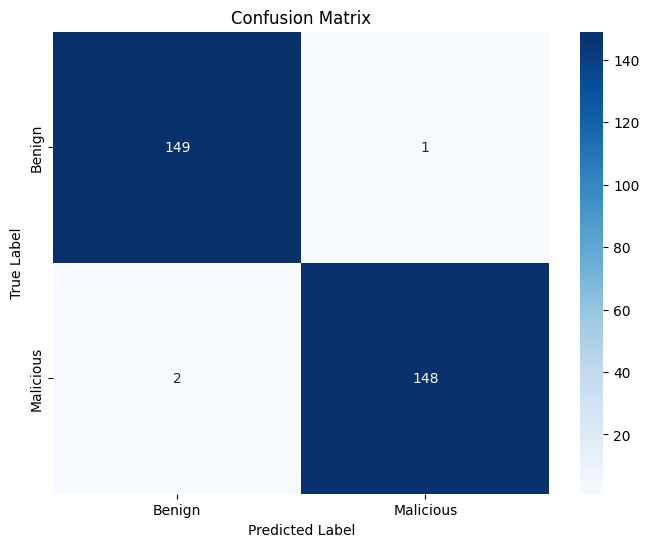

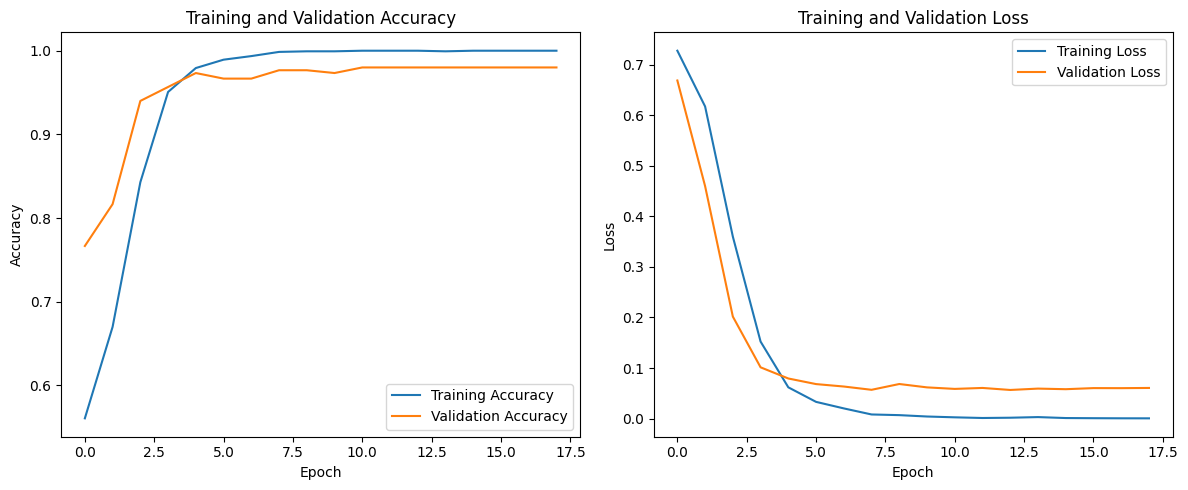

Model evaluation and visualization complete!


In [23]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Evaluate the model on the test set
loss, accuracy = model.evaluate(X_test, y_test, verbose=1)
print(f"\nTest Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

# Make predictions on the test set
y_pred_proba = model.predict(X_test)
y_pred = (y_pred_proba > 0.5).astype(int) # Convert probabilities to binary predictions

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign', 'Malicious'],
            yticklabels=['Benign', 'Malicious'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# Plot training history
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

print("Model evaluation and visualization complete!")

**Code Explanation (Cell `6e62686c`):**

*   `from sklearn.metrics import classification_report, confusion_matrix`: Imports functions from scikit-learn for generating evaluation metrics.
*   `import matplotlib.pyplot as plt` and `import seaborn as sns`: Imports libraries for data visualization.
*   `loss, accuracy = model.evaluate(X_test, y_test, verbose=1)`: Evaluates the trained model on the test dataset (`X_test`, `y_test`) and returns the test loss and test accuracy. `verbose=1` displays a progress bar.
*   `print(f"\nTest Loss: {loss:.4f}")`, `print(f"Test Accuracy: {accuracy:.4f}")`: Prints the calculated test loss and accuracy, formatted to four decimal places.
*   `y_pred_proba = model.predict(X_test)`: Generates probability predictions for the test set using the trained model.
*   `y_pred = (y_pred_proba > 0.5).astype(int)`: Converts the predicted probabilities into binary class labels (0 or 1) by applying a threshold of 0.5.
*   `print("\nClassification Report:")`, `print(classification_report(y_test, y_pred))`: Generates and prints a classification report comparing the true test labels (`y_test`) with the predicted labels (`y_pred`). This report includes precision, recall, F1-score, and support for each class.
*   `cm = confusion_matrix(y_test, y_pred)`: Computes the confusion matrix, which is a table showing the number of correct and incorrect predictions for each class.
*   `plt.figure(figsize=(8, 6))`, `sns.heatmap(...)`, `plt.xlabel(...)`, `plt.ylabel(...)`, `plt.title(...)`, `plt.show()`: These lines create a heatmap visualization of the confusion matrix using `seaborn`. The heatmap includes annotations (`annot=True`), displays integer values (`fmt='d'`), uses a 'Blues' color map, and sets custom x and y tick labels for clarity.
*   `plt.figure(figsize=(12, 5))`: Creates a new figure for plotting training history.
*   `plt.subplot(1, 2, 1)`, `plt.plot(...)`, `plt.title(...)`, `plt.xlabel(...)`, `plt.ylabel(...)`, `plt.legend()`: These lines create the first subplot displaying the training and validation accuracy over epochs. It plots the 'accuracy' and 'val_accuracy' values from the `history` object obtained during model training.
*   `plt.subplot(1, 2, 2)`, `plt.plot(...)`, `plt.title(...)`, `plt.xlabel(...)`, `plt.ylabel(...)`, `plt.legend()`: These lines create the second subplot, displaying the training and validation loss over epochs. It plots the 'loss' and 'val_loss' values from the `history` object.
*   `plt.tight_layout()`, `plt.show()`: Adjusts subplot parameters for a tight layout and displays the plots.
*   `print("Model evaluation and visualization complete!")`: Indicates the completion of the evaluation phase.

In [ ]:
# The 'preprocess_image' function is defined in a new, earlier cell for better code flow.
# This cell is now redundant.

Image Preprocessing setup complete. You can now use the 'preprocess_image' function.
